In [2]:
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn import metrics
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn import datasets
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.datasets import load_breast_cancer

In [3]:
data=load_breast_cancer()

In [4]:
x=data.data
y=data.target
df = pd.DataFrame(x, columns=data.feature_names)

In [5]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
x, y_true = make_blobs(n_samples = 250, centers = 5, cluster_std = 0.4, random_state = 0)

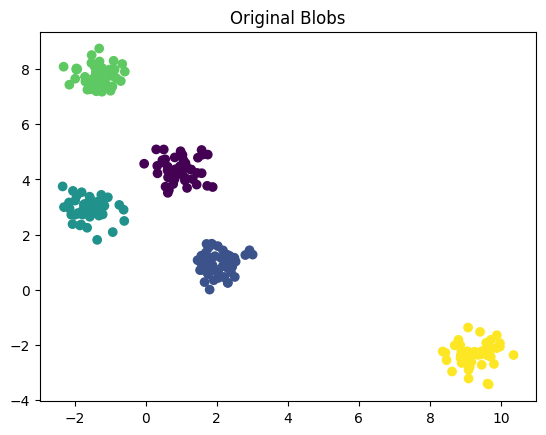

In [7]:
plt.scatter(x[:, 0], x[:, 1], c=y_true, cmap='viridis')
plt.title("Original Blobs")
plt.show()

In [8]:
db = DBSCAN(eps=0.4, min_samples=5, metric='euclidean')
labels = db.fit_predict(x)

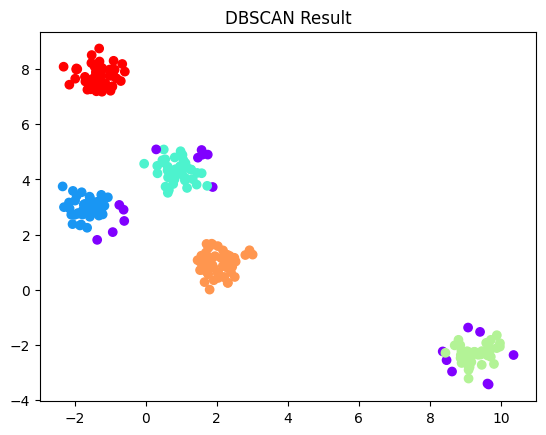

In [9]:
plt.scatter(x[:, 0], x[:, 1], c=labels, cmap='rainbow')
plt.title("DBSCAN Result")
plt.show()

In [10]:
print("Clusters found:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", list(labels).count(-1))
print("ARI:", adjusted_rand_score(y_true, labels))

Clusters found: 5
Noise points: 19
ARI: 0.8997940034388239


In [11]:
mask = labels != -1
x_filtered = x[mask]
labels_filtered = labels[mask]
# Silhouette score
score = silhouette_score(x_filtered, labels_filtered)
print("Silhouette Score:", score)

Silhouette Score: 0.8257081588323262
